Cell 1: 
This cell ensures that Python can find the project’s src/ folder when running inside a Jupyter notebook.

Jupyter does not automatically know where the project root is, so we manually add it to sys.path.

We then import standard libraries for data analysis and plotting, as well as our project’s custom functions for data cleaning, signal construction, backtesting, and metrics.

In [4]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)
print("src exists:", (ROOT / "src").exists())

from src.data_clean import clean_prices, to_monthly_prices, monthly_returns
from src.signals import momentum_12_1
from src.backtest import make_ls_weights, backtest_monthly
from src.metrics import annualized_sharpe, max_drawdown


Project root: C:\Users\Stefanie\Desktop\Machine Learning\Project 1 cross_sectional_momentum_research\cross_sectional_momentum_research
src exists: True


In [5]:
raw_path = ROOT / "data" / "raw" / "prices_daily.csv"
prices = pd.read_csv(raw_path, index_col=0, parse_dates=True).sort_index()

prices = clean_prices(prices, min_coverage=0.95)
mpx = to_monthly_prices(prices)
mret = monthly_returns(mpx)

mpx.shape, mret.shape


((192, 39), (192, 39))

In [6]:
LOOKBACK = 12
SKIP = 1

sig = momentum_12_1(mpx, lookback_months=LOOKBACK, skip_months=SKIP)

# We want to predict next-month returns, so align:
# signal at month t predicts returns at t+1
sig_aligned = sig
ret_fwd = mret.shift(-1)

sig_aligned.shape, ret_fwd.shape


((192, 39), (192, 39))

Signal summary:
count    7020.000000
mean        0.182569
std         0.298875
min        -0.689526
1%         -0.395058
5%         -0.201278
50%         0.149071
95%         0.639063
99%         1.175088
max         4.154545
dtype: float64


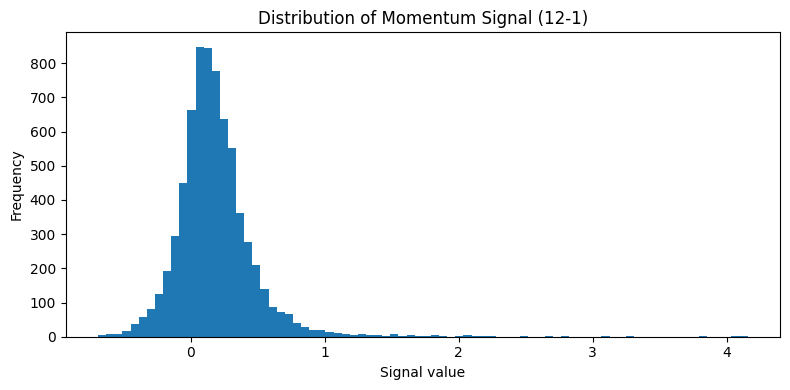

In [7]:
s = sig_aligned.stack().dropna()

print("Signal summary:")
print(s.describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(s, bins=80)
ax.set_title("Distribution of Momentum Signal (12-1)")
ax.set_xlabel("Signal value")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


In [8]:
def decile_forward_returns(sig_df: pd.DataFrame, fwd_ret_df: pd.DataFrame, n_bins: int = 10) -> pd.DataFrame:
    """
    For each date:
      - bucket stocks into deciles by signal
      - compute average next-month return per decile
    Returns a DataFrame indexed by date with columns 1..n_bins.
    """
    out = []
    for dt in sig_df.index:
        s = sig_df.loc[dt]
        r = fwd_ret_df.loc[dt]
        df = pd.concat([s.rename("sig"), r.rename("ret")], axis=1).dropna()
        if len(df) < 30:
            continue

        # qcut assigns bins with ~equal counts
        try:
            df["decile"] = pd.qcut(df["sig"], q=n_bins, labels=False) + 1
        except ValueError:
            # happens if too many ties
            continue

        means = df.groupby("decile")["ret"].mean()
        out.append(means.rename(dt))

    return pd.DataFrame(out).sort_index()


dec = decile_forward_returns(sig_aligned, ret_fwd, n_bins=10)
dec.tail(), dec.shape


(decile            1         2         3         4         5         6   \
 2025-07-31  0.092311  0.101184  0.064753 -0.004098  0.085830  0.049808   
 2025-08-31  0.018294 -0.017659  0.088805 -0.012524  0.007787 -0.041776   
 2025-09-30  0.030603  0.062855  0.022982  0.192789 -0.070409  0.053353   
 2025-10-31 -0.020870  0.040996  0.069083  0.018887 -0.007896 -0.049796   
 2025-11-30  0.058840  0.030724  0.005885  0.017086  0.006555  0.016527   
 
 decile            7         8         9         10  
 2025-07-31 -0.002357  0.045216  0.002667 -0.022353  
 2025-08-31  0.020677  0.012593 -0.001313  0.104129  
 2025-09-30 -0.009740  0.012329  0.066466  0.033044  
 2025-10-31  0.009573  0.016575  0.004280 -0.030066  
 2025-11-30 -0.001278  0.006536  0.018818 -0.059927  ,
 (179, 10))

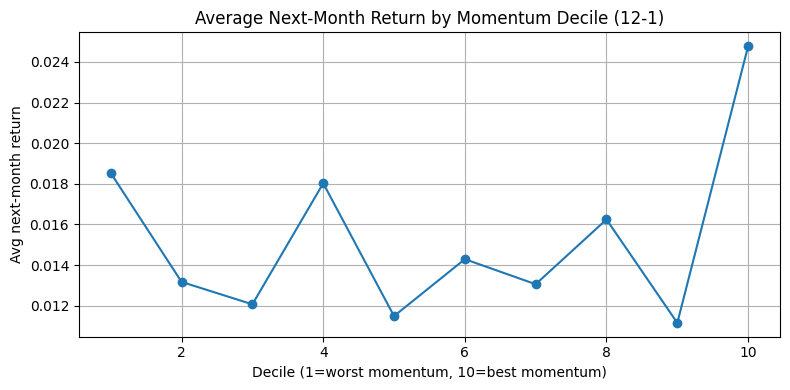

decile
1     0.018530
2     0.013167
3     0.012066
4     0.018024
5     0.011485
6     0.014288
7     0.013055
8     0.016244
9     0.011151
10    0.024777
dtype: float64

In [9]:
avg_by_decile = dec.mean()

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(avg_by_decile.index, avg_by_decile.values, marker="o") # type: ignore
ax.set_title("Average Next-Month Return by Momentum Decile (12-1)")
ax.set_xlabel("Decile (1=worst momentum, 10=best momentum)")
ax.set_ylabel("Avg next-month return")
ax.grid(True)
plt.tight_layout()
plt.show()

avg_by_decile


In [10]:
def make_long_only_weights(signal: pd.DataFrame, long_q: float = 0.9) -> pd.DataFrame:
    def one_date(s: pd.Series) -> pd.Series:
        s = s.dropna()
        if len(s) < 20:
            return pd.Series(dtype=float)
        thr = s.quantile(long_q)
        longs = s[s >= thr].index
        w = pd.Series(0.0, index=s.index)
        if len(longs) > 0:
            w.loc[longs] = 1.0 / len(longs)
        return w

    w = signal.apply(one_date, axis=1)
    return w.reindex_like(signal).fillna(0.0)


def make_short_only_weights(signal: pd.DataFrame, short_q: float = 0.1) -> pd.DataFrame:
    def one_date(s: pd.Series) -> pd.Series:
        s = s.dropna()
        if len(s) < 20:
            return pd.Series(dtype=float)
        thr = s.quantile(short_q)
        shorts = s[s <= thr].index
        w = pd.Series(0.0, index=s.index)
        if len(shorts) > 0:
            w.loc[shorts] = -1.0 / len(shorts)
        return w

    w = signal.apply(one_date, axis=1)
    return w.reindex_like(signal).fillna(0.0)


# Use your Experiment 2 parameters here:
LONG_Q = 0.9
SHORT_Q = 0.1
COST = 0.0

w_ls = make_ls_weights(sig_aligned, LONG_Q, SHORT_Q)
w_long = make_long_only_weights(sig_aligned, LONG_Q)
w_short = make_short_only_weights(sig_aligned, SHORT_Q)

res_ls = backtest_monthly(w_ls, mret, COST)
res_long = backtest_monthly(w_long, mret, COST)
res_short = backtest_monthly(w_short, mret, COST)

def summary(res, name):
    return {
        "name": name,
        "sharpe": annualized_sharpe(res["net_return"]),
        "max_dd": max_drawdown(res["equity"]),
        "final_equity": float(res["equity"].iloc[-1]),
        "avg_turnover": float(res["turnover"].mean()),
    }

pd.DataFrame([
    summary(res_ls, "LS (top/bottom 10%)"),
    summary(res_long, "Long only (top 10%)"),
    summary(res_short, "Short only (bottom 10%)"),
])


,name,sharpe,max_dd,final_equity,avg_turnover
0,LS (top/bottom 10%),0.279457,-0.666838,1.834729,1.091146
1,Long only (top 10%),1.310655,-0.234881,56.926549,0.494792
2,Short only (bottom 10%),-0.877589,-0.982684,0.021985,0.596354


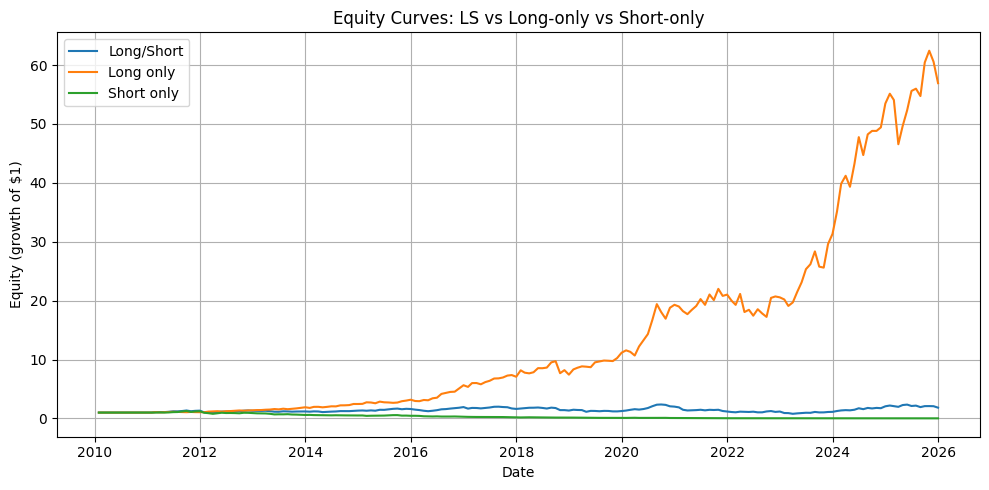

In [11]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(res_ls.index, res_ls["equity"], label="Long/Short")
ax.plot(res_long.index, res_long["equity"], label="Long only")
ax.plot(res_short.index, res_short["equity"], label="Short only")
ax.set_title("Equity Curves: LS vs Long-only vs Short-only")
ax.set_xlabel("Date")
ax.set_ylabel("Equity (growth of $1)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()
